# Tutorial 3: Sequential Inference (SNPE-C)

**Course:** AI4Science — Simulation-Based Inference\
**Lecture link:** Lecture II, Part I (Sequential SBI, SNPE-A/B/C)

---

### Learning objectives
- Run multi-round SNPE-C and compare with single-round NPE
- Observe the focusing of the proposal distribution across rounds
- Understand the simulation-efficiency gain vs loss of amortisation

> **Runtime:** Select **GPU** in Colab


In [ ]:
!pip install -q sbi torch matplotlib

import torch
import matplotlib.pyplot as plt
from sbi.utils import BoxUniform
from sbi.inference import NPE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.utils.user_input_checks import process_prior, process_simulator, check_sbi_inputs

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.0/460.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 568.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00

## 1. Problem: Broad Prior

In [ ]:
num_dim = 3
prior = BoxUniform(low=-10 * torch.ones(num_dim), high=10 * torch.ones(num_dim))

def simulator(theta):
    return theta + 0.5 * torch.randn_like(theta)

prior, _, prn = process_prior(prior)
sim_fn = process_simulator(simulator, prior, prn)
check_sbi_inputs(sim_fn, prior)

theta_true = torch.tensor([2.5, -1.0, 3.0])
x_o = torch.tensor([2.7, -0.8, 2.9])
print(f"Prior range: [-10, 10]^3 — very broad!")
print(f"True θ:      {theta_true.numpy()}")
print(f"Observation: {x_o.numpy()}")


Prior range: [-10, 10]^3 — very broad!
True θ:      [ 2.5 -1.   3. ]
Observation: [ 2.7 -0.8  2.9]


## 2. Single-Round Baseline

In [ ]:
num_sims_total = 2000

theta_1r, x_1r = simulate_for_sbi(sim_fn, prior, num_simulations=num_sims_total)
inf_1r = NPE(prior, density_estimator="nsf")
inf_1r.append_simulations(theta_1r, x_1r)
inf_1r.train(show_train_summary=False)
posterior_1r = inf_1r.build_posterior()
samples_1r = posterior_1r.sample((5000,), x=x_o)
print(f"✓ Single-round done — posterior std: {samples_1r.std(dim=0).numpy()}")


  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 115 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

✓ Single-round done — posterior std: [0.5407878  0.65223175 0.6618098 ]


/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


## 3. Multi-Round SNPE-C

In [ ]:
num_rounds = 3
sims_per_round = 667

inf_seq = NPE(prior, density_estimator="nsf")
proposal = prior
posteriors_per_round = []

for r in range(num_rounds):
    print(f"\n--- Round {r+1}/{num_rounds} ---")
    theta_r, x_r = simulate_for_sbi(sim_fn, proposal, num_simulations=sims_per_round)
    inf_seq.append_simulations(theta_r, x_r, proposal=proposal)
    de = inf_seq.train(show_train_summary=False)
    post_r = inf_seq.build_posterior(de)
    posteriors_per_round.append(post_r)
    proposal = post_r.set_default_x(x_o)
    s = post_r.sample((1000,), x=x_o)
    print(f"  mean: {s.mean(dim=0).numpy()},  std: {s.std(dim=0).numpy()}")
print("\n✓ Sequential NPE done")



--- Round 1/3 ---


  0%|          | 0/667 [00:00<?, ?it/s]

 Neural network successfully converged after 145 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

  mean: [ 2.7090664  -0.65896344  2.9647732 ],  std: [1.0332091  0.75354105 0.74834114]

--- Round 2/3 ---


...

  0%|          | 0/667 [00:00<?, ?it/s]

  0%|          | 0/667 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 57 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

  mean: [ 2.7922602 -0.8655816  2.8902965],  std: [0.68233746 0.69005525 0.7083931 ]

✓ Sequential NPE done


## 4. Compare

  0%|          | 0/5000 [00:00<?, ?it/s]

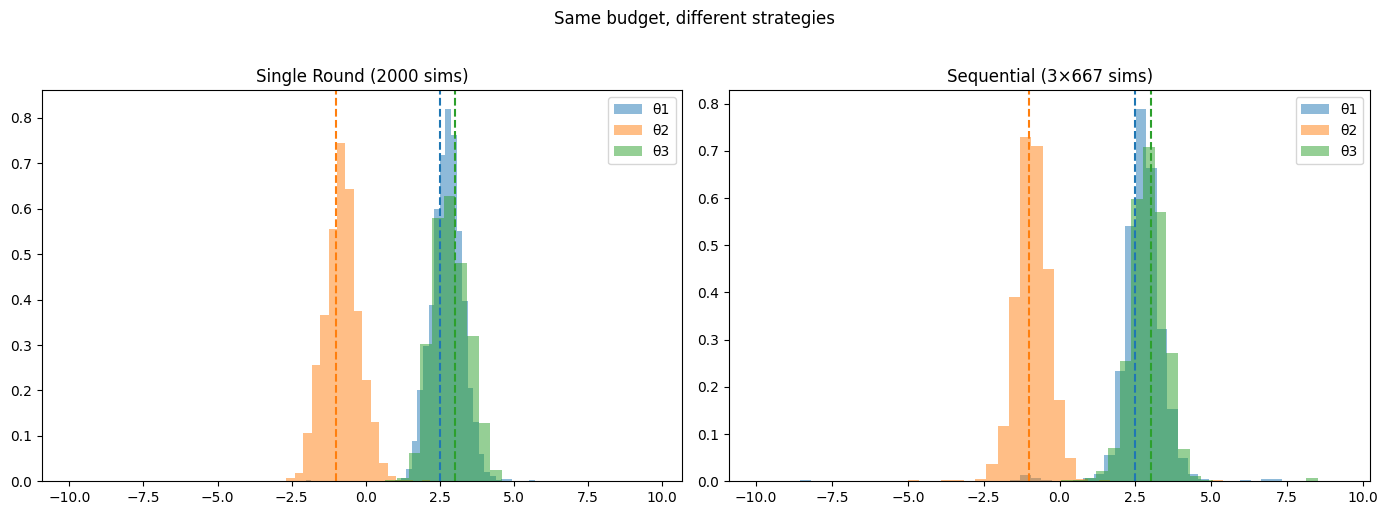

In [ ]:
samples_seq = posteriors_per_round[-1].sample((5000,), x=x_o)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for d in range(num_dim):
    axes[0].hist(samples_1r[:, d].numpy(), bins=50, alpha=0.5, density=True, label=f"θ{d+1}")
    axes[1].hist(samples_seq[:, d].numpy(), bins=50, alpha=0.5, density=True, label=f"θ{d+1}")
for ax, title in [(axes[0], "Single Round (2000 sims)"), (axes[1], f"Sequential ({num_rounds}×{sims_per_round} sims)")]:
    for d in range(num_dim): ax.axvline(theta_true[d].item(), color=f"C{d}", ls="--", lw=1.5)
    ax.set_title(title); ax.legend()
plt.suptitle("Same budget, different strategies", y=1.02)
plt.tight_layout(); plt.show()


## 5. Proposal Focusing

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

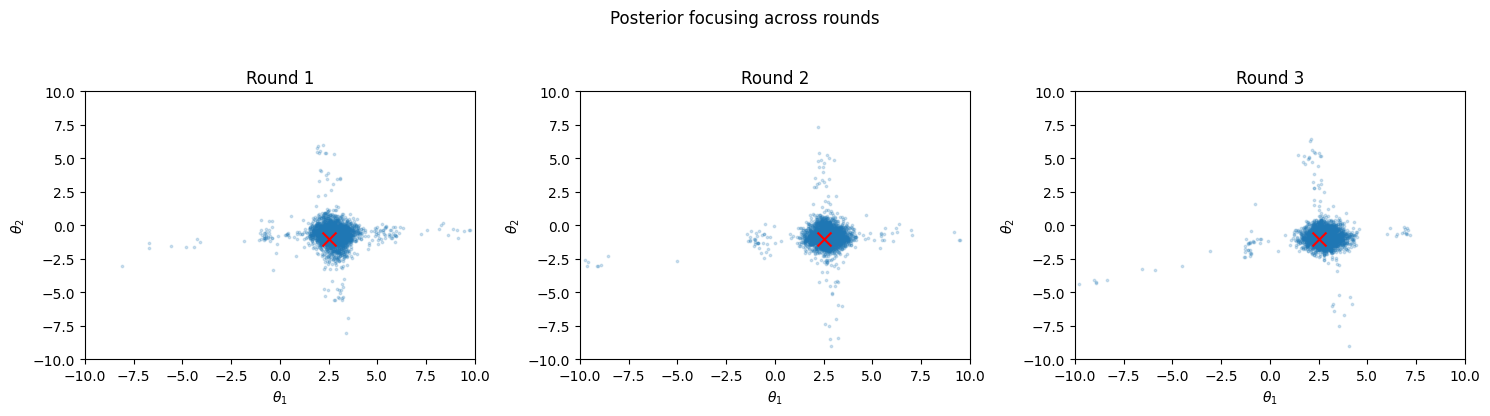

In [ ]:
fig, axes = plt.subplots(1, num_rounds, figsize=(5*num_rounds, 4))
for r, post_r in enumerate(posteriors_per_round):
    s = post_r.sample((3000,), x=x_o)
    ax = axes[r]
    ax.scatter(s[:, 0].numpy(), s[:, 1].numpy(), alpha=0.2, s=3)
    ax.scatter([theta_true[0].item()], [theta_true[1].item()], color="red", marker="x", s=100, zorder=5)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel("$\\theta_1$"); ax.set_ylabel("$\\theta_2$")
    ax.set_title(f"Round {r+1}")
plt.suptitle("Posterior focusing across rounds", y=1.03)
plt.tight_layout(); plt.show()


## 6. Exercises

**Exercise 1:** Try 5 rounds with 400 sims each. Does it keep improving?

**Exercise 2:** Set prior to $[-50, 50]^3$. Does single-round fail? Does sequential still work?

**Exercise 3:** After sequential inference, evaluate the posterior at a very different $x'$. Is it still accurate? (Tests loss of amortisation.)


<details>
<summary><b>▶ Solution — Exercise 1: More rounds</b></summary>

More rounds generally help, but with diminishing returns. After ~3–5 rounds the posterior is usually well-concentrated and additional rounds add little. The marginal cost is the sequential overhead (can't parallelise across rounds).
</details>

  0%|          | 0/400 [00:00<?, ?it/s]

 Neural network successfully converged after 195 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 48 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

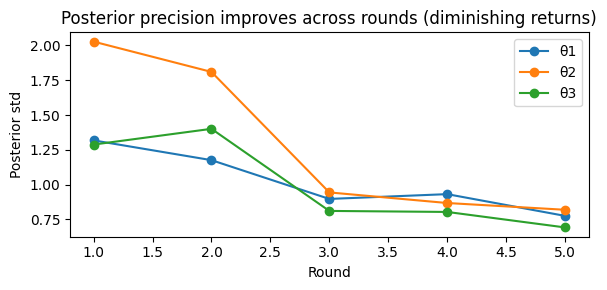

In [ ]:
# === SOLUTION: Exercise 1 — 5 rounds ===
inf_5r = NPE(prior, density_estimator="nsf")
proposal_5r = prior
stds_per_round = []

for r in range(5):
    theta_r, x_r = simulate_for_sbi(sim_fn, proposal_5r, num_simulations=400)
    inf_5r.append_simulations(theta_r, x_r, proposal=proposal_5r)
    de = inf_5r.train(show_train_summary=False)
    post_r = inf_5r.build_posterior(de)
    proposal_5r = post_r.set_default_x(x_o)
    s = post_r.sample((1000,), x=x_o)
    stds_per_round.append(s.std(dim=0).numpy())

fig, ax = plt.subplots(figsize=(6, 3))
for d in range(num_dim):
    ax.plot(range(1, 6), [s[d] for s in stds_per_round], 'o-', label=f"θ{d+1}")
ax.set_xlabel("Round"); ax.set_ylabel("Posterior std"); ax.legend()
ax.set_title("Posterior precision improves across rounds (diminishing returns)")
plt.tight_layout(); plt.show()


<details>
<summary><b>▶ Solution — Exercise 2: Very broad prior</b></summary>

With a $[-50, 50]^3$ prior, single-round NPE with 2000 sims will almost certainly fail — the training data is spread too thin. Sequential methods still work because they progressively zoom in.
</details>

In [ ]:
# === SOLUTION: Exercise 2 — Prior [-50, 50]^3 ===
prior_broad = BoxUniform(low=-50*torch.ones(3), high=50*torch.ones(3))
prior_broad, _, prn_b = process_prior(prior_broad)
sim_b = process_simulator(simulator, prior_broad, prn_b)

# Single round
theta_b, x_b = simulate_for_sbi(sim_b, prior_broad, num_simulations=2000)
inf_b = NPE(prior_broad, density_estimator="nsf")
inf_b.append_simulations(theta_b, x_b)
inf_b.train(show_train_summary=False)
post_b = inf_b.build_posterior()
s_b = post_b.sample((1000,), x=x_o)
print(f"Single-round posterior std with [-50,50] prior: {s_b.std(dim=0).numpy()}")
print("→ Very wide! The network cannot focus with so few sims in such a large prior.")

# Sequential (3 rounds)
inf_bs = NPE(prior_broad, density_estimator="nsf")
prop_bs = prior_broad
for r in range(3):
    t, x = simulate_for_sbi(sim_b, prop_bs, num_simulations=667)
    inf_bs.append_simulations(t, x, proposal=prop_bs)
    de = inf_bs.train(show_train_summary=False)
    p = inf_bs.build_posterior(de)
    prop_bs = p.set_default_x(x_o)
s_bs = p.sample((1000,), x=x_o)
print(f"Sequential posterior std with [-50,50] prior:   {s_bs.std(dim=0).numpy()}")
print("→ Sequential recovers a focused posterior despite the huge prior!")



  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 112 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

Single-round posterior std with [-50,50] prior: [2.4441292 2.3893325 3.091564 ]
→ Very wide! The network cannot focus with so few sims in such a large prior.


  0%|          | 0/667 [00:00<?, ?it/s]

...

  0%|          | 0/667 [00:00<?, ?it/s]

  0%|          | 0/667 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 33 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

Sequential posterior std with [-50,50] prior:   [3.1455276 3.896748  5.8932686]
→ Sequential recovers a focused posterior despite the huge prior!


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

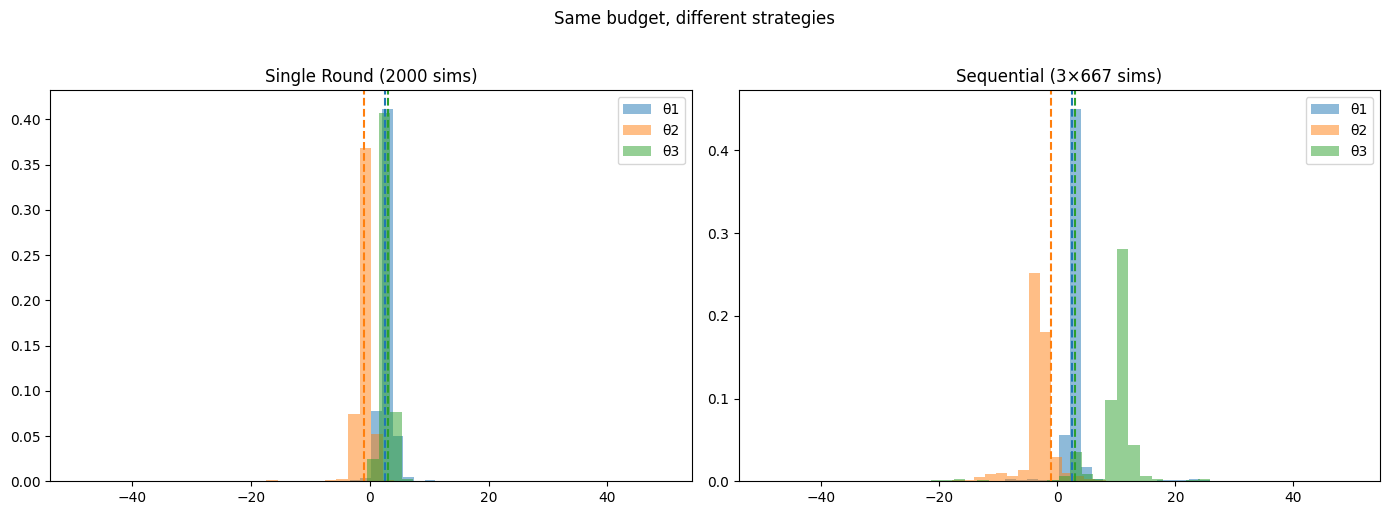

In [ ]:
samples_seq = p.sample((5000,), x=x_o)
samples_1r = post_b.sample((5000,), x=x_o)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for d in range(num_dim):
    axes[0].hist(samples_1r[:, d].numpy(), bins=50, alpha=0.5, density=True, label=f"θ{d+1}")
    axes[1].hist(samples_seq[:, d].numpy(), bins=50, alpha=0.5, density=True, label=f"θ{d+1}")
for ax, title in [(axes[0], "Single Round (2000 sims)"), (axes[1], f"Sequential ({num_rounds}×{sims_per_round} sims)")]:
    for d in range(num_dim): ax.axvline(theta_true[d].item(), color=f"C{d}", ls="--", lw=1.5)
    ax.set_title(title); ax.legend()
plt.suptitle("Same budget, different strategies", y=1.02)
plt.tight_layout(); plt.show()

<details>
<summary><b>▶ Solution — Exercise 3: Loss of amortisation</b></summary>

After sequential inference focused on $x_o$, the posterior is only accurate near $x_o$.
Evaluating at a very different observation will give nonsensical results. This is the fundamental trade-off: sequential = more efficient but not amortised.
</details>

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

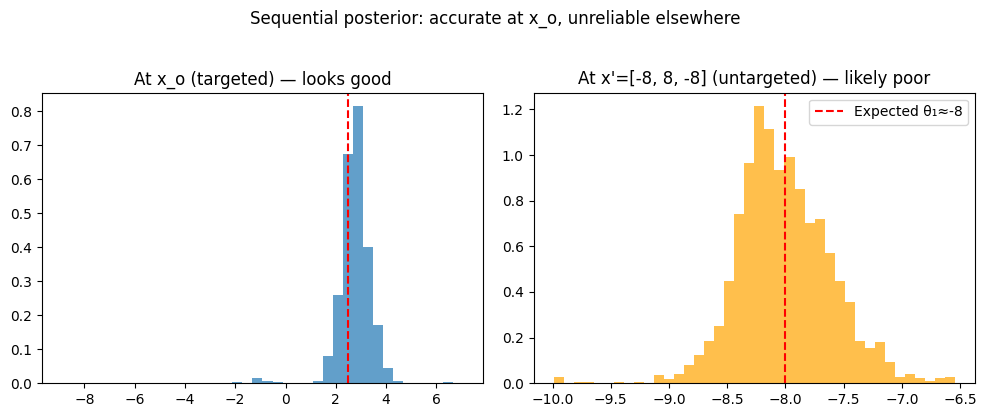

⚠ The sequential posterior is NOT amortised — only trust it near x_o!


In [ ]:
# === SOLUTION: Exercise 3 — Loss of amortisation ===
x_different = torch.tensor([-8.0, 8.0, -8.0])  # Far from x_o
s_at_xo = posteriors_per_round[-1].sample((2000,), x=x_o)
s_at_xdiff = posteriors_per_round[-1].sample((2000,), x=x_different)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(s_at_xo[:, 0].numpy(), bins=40, density=True, alpha=0.7)
axes[0].axvline(theta_true[0].item(), color='red', ls='--')
axes[0].set_title(f"At x_o (targeted) — looks good")

axes[1].hist(s_at_xdiff[:, 0].numpy(), bins=40, density=True, alpha=0.7, color='orange')
axes[1].axvline(-8.0, color='red', ls='--', label='Expected θ₁≈-8')
axes[1].set_title(f"At x'=[-8, 8, -8] (untargeted) — likely poor")
axes[1].legend()

plt.suptitle("Sequential posterior: accurate at x_o, unreliable elsewhere", y=1.03)
plt.tight_layout(); plt.show()
print("⚠ The sequential posterior is NOT amortised — only trust it near x_o!")


---
**Next:** Tutorial 4 covers diagnostics to validate these posteriors.